# Chapter 75 — Why Character-Level GPT Is Not Enough

Character-level GPT made token IDs, shifted targets, training, and generation easy to inspect.

This chapter explains why that clarity comes with important efficiency and representation tradeoffs.

## Learning goals

By the end of this chapter, you will be able to:

- explain character, word, and subword tokenization;
- describe the teaching strengths of character tokens;
- connect token count to autoregressive generation steps;
- connect sequence length to attention-table size;
- compare token counts for one sentence;
- explain the vocabulary-size versus sequence-length tradeoff;
- identify limitations of fixed word vocabularies;
- explain why larger tokens are not automatically better; and
- motivate learned subword tokenization as the next step.

## Tokens and tokenizers

A **token** is one text unit represented by one token ID.

A **tokenizer** converts text to tokens and IDs and defines how IDs decode back to text.

A **vocabulary** is the finite set of tokens available to that tokenizer.

**Sequence length** is the number of tokens in a model input.

A character token represents a small written unit, a word token represents a word-like unit, and a subword token represents a reusable piece that may be smaller than a word.

Technically, characters are also tokens.

When this course contrasts character-level and token-level models, **token-level** means tokens larger than individual characters, usually subwords.

## Why character-level GPT was a useful first model

Character tokenization has several teaching advantages:

- the vocabulary is small;
- token boundaries are visible;
- encoding and decoding need little machinery;
- spaces, punctuation, capitalization, and newlines remain explicit; and
- a model can compose an unseen word when every required character is already in its vocabulary.

That final condition matters because a fixed character vocabulary can still fail on a previously unseen writing symbol.

Character-level modeling avoids unknown **words**, but it does not automatically avoid unknown **characters**.

## Count character tokens

The chapter uses one sentence for all three tokenization styles.

Python's `list(text)` provides the same simple splitting behavior used by our teaching tokenizer.

In [1]:
sentence = "The unbelievable rabbit was running mysteriously."
character_tokens = list(sentence)

print("sentence:")
print(sentence)
print()
print("character tokens:")
print(character_tokens)
print("character-token count:", len(character_tokens))

sentence:
The unbelievable rabbit was running mysteriously.

character tokens:
['T', 'h', 'e', ' ', 'u', 'n', 'b', 'e', 'l', 'i', 'e', 'v', 'a', 'b', 'l', 'e', ' ', 'r', 'a', 'b', 'b', 'i', 't', ' ', 'w', 'a', 's', ' ', 'r', 'u', 'n', 'n', 'i', 'n', 'g', ' ', 'm', 'y', 's', 't', 'e', 'r', 'i', 'o', 'u', 's', 'l', 'y', '.']
character-token count: 49


## A Unicode caveat

Python iterates a string by Unicode code points, which do not always match user-perceived characters called grapheme clusters.

The precomposed `é` and the visually similar sequence `e` plus a combining accent demonstrate the difference.

In [2]:
precomposed_text = "é"
decomposed_text = "e\u0301"

print("precomposed display:", precomposed_text)
print("precomposed tokens:", list(precomposed_text))
print("precomposed token count:", len(list(precomposed_text)))
print()
print("decomposed display:", decomposed_text)
print("decomposed tokens:", list(decomposed_text))
print("decomposed token count:", len(list(decomposed_text)))

precomposed display: é
precomposed tokens: ['é']
precomposed token count: 1

decomposed display: é
decomposed tokens: ['e', '́']
decomposed token count: 2


## Compare a toy word tokenizer

The next function groups alphanumeric runs and keeps non-whitespace punctuation as separate tokens.

It is an instructional rule, not a production tokenizer, and it does not preserve spaces as tokens.

A complete tokenizer would also need explicit decoding rules for reconstructing whitespace and punctuation.

In [3]:
def simple_word_tokenize(text: str) -> list[str]:
    tokens = []
    current_word = ""
    for character in text:
        if character.isalnum():
            current_word += character
            continue
        if current_word:
            tokens.append(current_word)
            current_word = ""
        if not character.isspace():
            tokens.append(character)
    if current_word:
        tokens.append(current_word)
    return tokens


word_tokens = simple_word_tokenize(sentence)
print("word tokens:")
print(word_tokens)
print("word-token count:", len(word_tokens))

word tokens:
['The', 'unbelievable', 'rabbit', 'was', 'running', 'mysteriously', '.']
word-token count: 7


A word vocabulary shortens this sentence, but a fixed word inventory has costs:

- inflections such as `run`, `runs`, and `running` may occupy separate entries;
- names, typos, and new terms may be absent;
- vocabulary size can grow rapidly across topics and languages; and
- unknown words require a fallback policy.

Replacing every unknown word with one unknown-token ID discards its spelling and internal structure.

## Illustrate subword pieces

Production subword vocabularies are learned from a corpus by a specified algorithm.

This notebook instead uses three hand-authored splits so their purpose is completely explicit.

The pieces do not claim to match any real tokenizer.

In [4]:
teaching_subword_splits = {
    "unbelievable": ["un", "believ", "able"],
    "running": ["run", "ning"],
    "mysteriously": ["mysteri", "ous", "ly"],
}


def teaching_subword_tokenize(text: str, split_map: dict[str, list[str]]) -> list[str]:
    tokens = []
    for word_or_punctuation in simple_word_tokenize(text):
        pieces = split_map.get(word_or_punctuation.lower())
        if pieces is None:
            tokens.append(word_or_punctuation)
        else:
            tokens.extend(pieces)
    return tokens


subword_tokens = teaching_subword_tokenize(sentence, teaching_subword_splits)
print("teaching subword tokens:")
print(subword_tokens)
print("subword-token count:", len(subword_tokens))

teaching subword tokens:
['The', 'un', 'believ', 'able', 'rabbit', 'was', 'run', 'ning', 'mysteri', 'ous', 'ly', '.']
subword-token count: 12


Subword tokenization often yields a practical middle ground, but its token count is not mathematically guaranteed to fall between character and word counts for every text.

The result depends on the learned vocabulary, normalization, whitespace rules, byte fallback, and the input itself.

A useful subword system can keep frequent patterns intact while decomposing rarer strings into available pieces.

## Compare sequence length and attention tables

For a sequence of length `T`, each attention head creates a `T × T` score table for each batch item.

The entry count `T²` is a useful sequence-length proxy, although a complete runtime estimate also depends on batch size, heads, width, implementation, and hardware.

One two-panel figure shows both the direct token count and its quadratic score-table consequence.

style              | tokens | T-squared entries
------------------------------------------------
characters         |     49 |              2401
words              |      7 |                49
teaching subwords  |     12 |               144


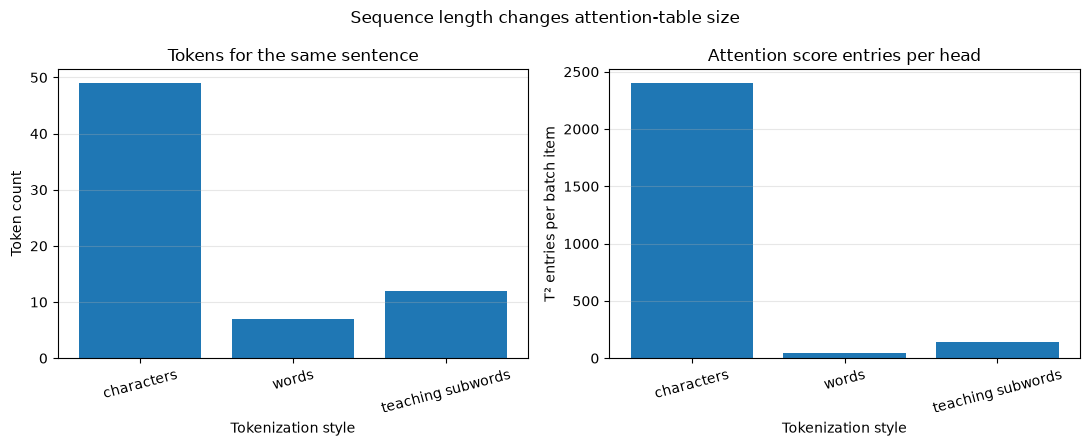

In [5]:
import matplotlib.pyplot as plt

tokenizations = {
    "characters": character_tokens,
    "words": word_tokens,
    "teaching subwords": subword_tokens,
}
token_counts = {name: len(tokens) for name, tokens in tokenizations.items()}
attention_entries = {name: count**2 for name, count in token_counts.items()}

print("style              | tokens | T-squared entries")
print("-" * 48)
for style in tokenizations:
    print(f"{style:<18} | {token_counts[style]:>6} | {attention_entries[style]:>17}")

figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
styles = list(token_counts)
axes[0].bar(styles, [token_counts[style] for style in styles])
axes[0].set_title("Tokens for the same sentence")
axes[0].set_ylabel("Token count")
axes[1].bar(styles, [attention_entries[style] for style in styles])
axes[1].set_title("Attention score entries per head")
axes[1].set_ylabel("T² entries per batch item")
for axis in axes:
    axis.set_xlabel("Tokenization style")
    axis.tick_params(axis="x", rotation=15)
    axis.grid(axis="y", alpha=0.3)
figure.suptitle("Sequence length changes attention-table size")
figure.tight_layout()
plt.show()

## Connect token count to generation

Autoregressive generation produces one token per forward pass in the simple loop from Chapter 72.

Generating this sentence after an empty starting point would therefore require one decision per token under the chosen tokenizer.

The comparison is illustrative because real generation normally begins with a prompt and may stop at a special end token.

In [6]:
print("approximate generation decisions for the sentence:")
for style, count in token_counts.items():
    print(f"{style:<18} {count:>3}")

repeated_text = (sentence + " ") * 4
context_limit = 20
visible_character_tokens = list(repeated_text)[:context_limit]
visible_word_tokens = simple_word_tokenize(repeated_text)[:context_limit]
visible_subword_tokens = teaching_subword_tokenize(
    repeated_text, teaching_subword_splits
)[:context_limit]

print()
print("first 20 character tokens:")
print(repr("".join(visible_character_tokens)))
print("first 20 word tokens:")
print(visible_word_tokens)
print("first 20 teaching subword tokens:")
print(visible_subword_tokens)

approximate generation decisions for the sentence:
characters          49
words                7
teaching subwords   12

first 20 character tokens:
'The unbelievable rab'
first 20 word tokens:
['The', 'unbelievable', 'rabbit', 'was', 'running', 'mysteriously', '.', 'The', 'unbelievable', 'rabbit', 'was', 'running', 'mysteriously', '.', 'The', 'unbelievable', 'rabbit', 'was', 'running', 'mysteriously']
first 20 teaching subword tokens:
['The', 'un', 'believ', 'able', 'rabbit', 'was', 'run', 'ning', 'mysteri', 'ous', 'ly', '.', 'The', 'un', 'believ', 'able', 'rabbit', 'was', 'run', 'ning']


With the same 20-token context limit, the character representation covers only part of the first sentence.

The word and teaching-subword representations cover more linguistic material because each token can span several characters.

This does not prove that larger tokens understand more.

It only shows that token boundaries change how much raw text fits into a fixed token budget.

## Character sequences spend positions on spelling

A character model must learn that letters form recurring word patterns before those patterns can support phrase and sentence predictions.

For example, producing `rabbit` requires six character decisions in this tokenizer.

A subword vocabulary might represent that string with one piece or several pieces depending on training data.

Fewer decisions can reduce generation latency and opportunities for drift, but an incorrect larger token can also change more text at once.

Token size changes the prediction problem rather than removing difficulty.

## Larger vocabularies also cost parameters

Shorter sequences are not free because every vocabulary item needs an input embedding and an output score.

The next table uses hypothetical vocabulary sizes and embedding dimension `64`.

It counts an untied input embedding, output weight, and output bias only.

Real configurations vary, and weight tying can share the input and output matrices.

In [7]:
embedding_dimension = 64
illustrative_vocabulary_sizes = {
    "character example": 100,
    "subword example": 32_000,
    "word example": 100_000,
}

print("illustrative style | vocabulary | embedding + output parameters")
print("-" * 67)
for style, vocabulary_size in illustrative_vocabulary_sizes.items():
    vocabulary_parameters = (
        vocabulary_size * embedding_dimension
        + embedding_dimension * vocabulary_size
        + vocabulary_size
    )
    print(f"{style:<18} | {vocabulary_size:>10,} | {vocabulary_parameters:>29,}")

illustrative style | vocabulary | embedding + output parameters
-------------------------------------------------------------------
character example  |        100 |                        12,900
subword example    |     32,000 |                     4,128,000
word example       |    100,000 |                    12,900,000


## The vocabulary-sequence tradeoff

| Style | Typical relative vocabulary | Typical relative sequence | Unseen strings | Main pressure |
|---|---:|---:|---|---|
| Character | Small | Long | Composable from known characters | Many positions and generation steps |
| Word | Large | Short | Needs unknown-word handling | Large embedding and output layers |
| Subword | Medium to large | Medium | Often decomposable into known pieces | Learned tokenizer complexity |

These are tendencies rather than universal numeric ranges.

Language, domain, normalization, training corpus, vocabulary budget, and tokenizer algorithm all affect the result.

## Larger tokens are not automatically better

Whole-word tokens reduce token count but can create brittle, extremely large vocabularies.

Related forms such as `run`, `runs`, `runner`, and `running` may not share parameters through their token identities.

Character tokens share spelling units broadly but require longer sequences and more steps.

Subword tokenization seeks reusable pieces, but a poor learned vocabulary can still split text inefficiently or encode undesirable corpus patterns.

Model quality also depends on data, capacity, optimization, context, and decoding, so tokenization alone does not determine performance.

## Related byte-level representations

A byte-level model uses byte values rather than Unicode code points.

The base byte inventory has 256 values, with implementations often adding special tokens.

Bytes can represent any text after encoding, but one visible symbol may require multiple byte tokens.

Byte models therefore avoid unknown text symbols while retaining much of the long-sequence pressure of small token units.

Some practical tokenizers also use byte fallback inside a larger subword system.

## Why learned subwords are the next step

Many practical language models use learned subword vocabularies because common strings can become compact tokens while rarer strings remain decomposable.

A real tokenizer must specify:

- text normalization;
- a training algorithm and corpus;
- vocabulary size;
- whitespace and punctuation representation;
- unknown or byte-fallback behavior;
- special tokens; and
- exact encode-decode behavior.

The transformer architecture can remain mostly unchanged while vocabulary size and token sequences change.

## Common mistakes

- Do not treat Python code points as universally identical to visible characters.
- Do not claim a character model can emit symbols absent from its fixed vocabulary.
- Do not treat the hand-authored splits in this notebook as a learned tokenizer.
- Do not assume subword token count always lies between word and character counts.
- Do not compare context lengths across tokenizers without considering the text each token represents.
- Do not use `T²` attention entries as a complete runtime estimate.
- Do not ignore embedding and output costs when increasing vocabulary size.
- Do not expect tokenization alone to fix a weak model or dataset.

## Takeaways

Character-level GPT is transparent, has a small vocabulary, and can compose unseen words from known character tokens.

Its long sequences require more attention entries, more context positions, and more autoregressive decisions for the same text.

Whole-word tokenization shortens sequences but creates vocabulary and unknown-word problems.

Learned subwords offer a configurable compromise rather than a guaranteed optimum.

> Tokenization trades vocabulary pressure against sequence pressure, and neither larger nor smaller tokens are automatically better.

## What comes next

The next chapter will replace hand-authored teaching splits with a systematic larger-than-character tokenization workflow.

That transition introduces vocabulary construction, exact encoding and decoding, special cases, and the model-dimension changes caused by a new vocabulary.